# Project Report: Filter-Based Feature Selection with Multi-Class LDA

This notebook consolidates the complete project workflow into one academic-style experimental report, covering dataset inspection, data validation, exploratory analysis, feature ranking, leakage-safe model evaluation, and robustness analyses.


## 1. Introduction

The objective of this project is to evaluate how different **filter-based feature selection criteria** influence the performance of a **Multi-Class Linear Discriminant Analysis (LDA)** classifier.

We implement five ranking methods from scratch:
- Pearson correlation
- Spearman correlation
- Chi-square statistic
- Information gain (entropy reduction)
- Gini gain (impurity reduction)

All experiments use a leakage-safe cross-validation design where feature ranking is computed **inside each training fold only**.


## 2. Dataset Description

We use the built-in **Wine** multi-class dataset from scikit-learn:
- 178 samples
- 13 numeric features
- 3 classes

This satisfies the project constraints (multi-class, at least 6 features, and no missing values expected).


In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)

wine = load_wine(as_frame=True)
df = wine.frame.copy()
target_col = 'target'
feature_cols = [c for c in df.columns if c != target_col]

print('Dataset shape:', df.shape)
print('Number of features:', len(feature_cols))
print('Class labels:', sorted(df[target_col].unique().tolist()))

Dataset shape: (178, 14)
Number of features: 13
Class labels: [0, 1, 2]


## 3. Data Validation

Before modeling, we validate structure and quality: data types, missing values, duplicates, and basic sanity checks.


In [53]:
display(df.head())
print('\nData types:')
print(df.dtypes)

print('\nMissing values per column:')
print(df.isna().sum())

print('\nDuplicate rows:', df.duplicated().sum())

print('\nClass distribution (counts):')
print(df[target_col].value_counts().sort_index())


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Data types:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Missing values per column:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315

## 4. Exploratory Data Analysis

This section examines class balance, feature distributions, class-conditional behavior, and inter-feature relationships.


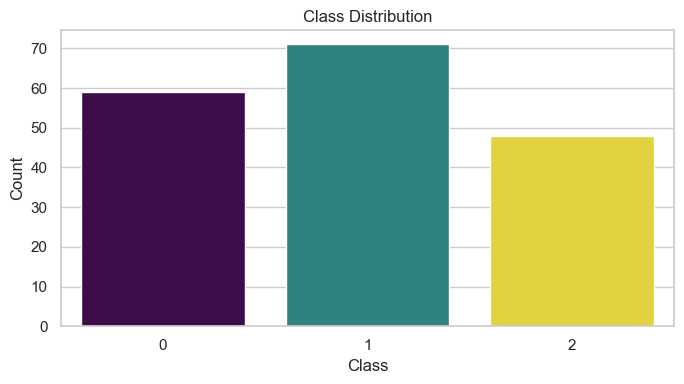

In [54]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=target_col, hue=target_col, palette='viridis', legend=False)
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


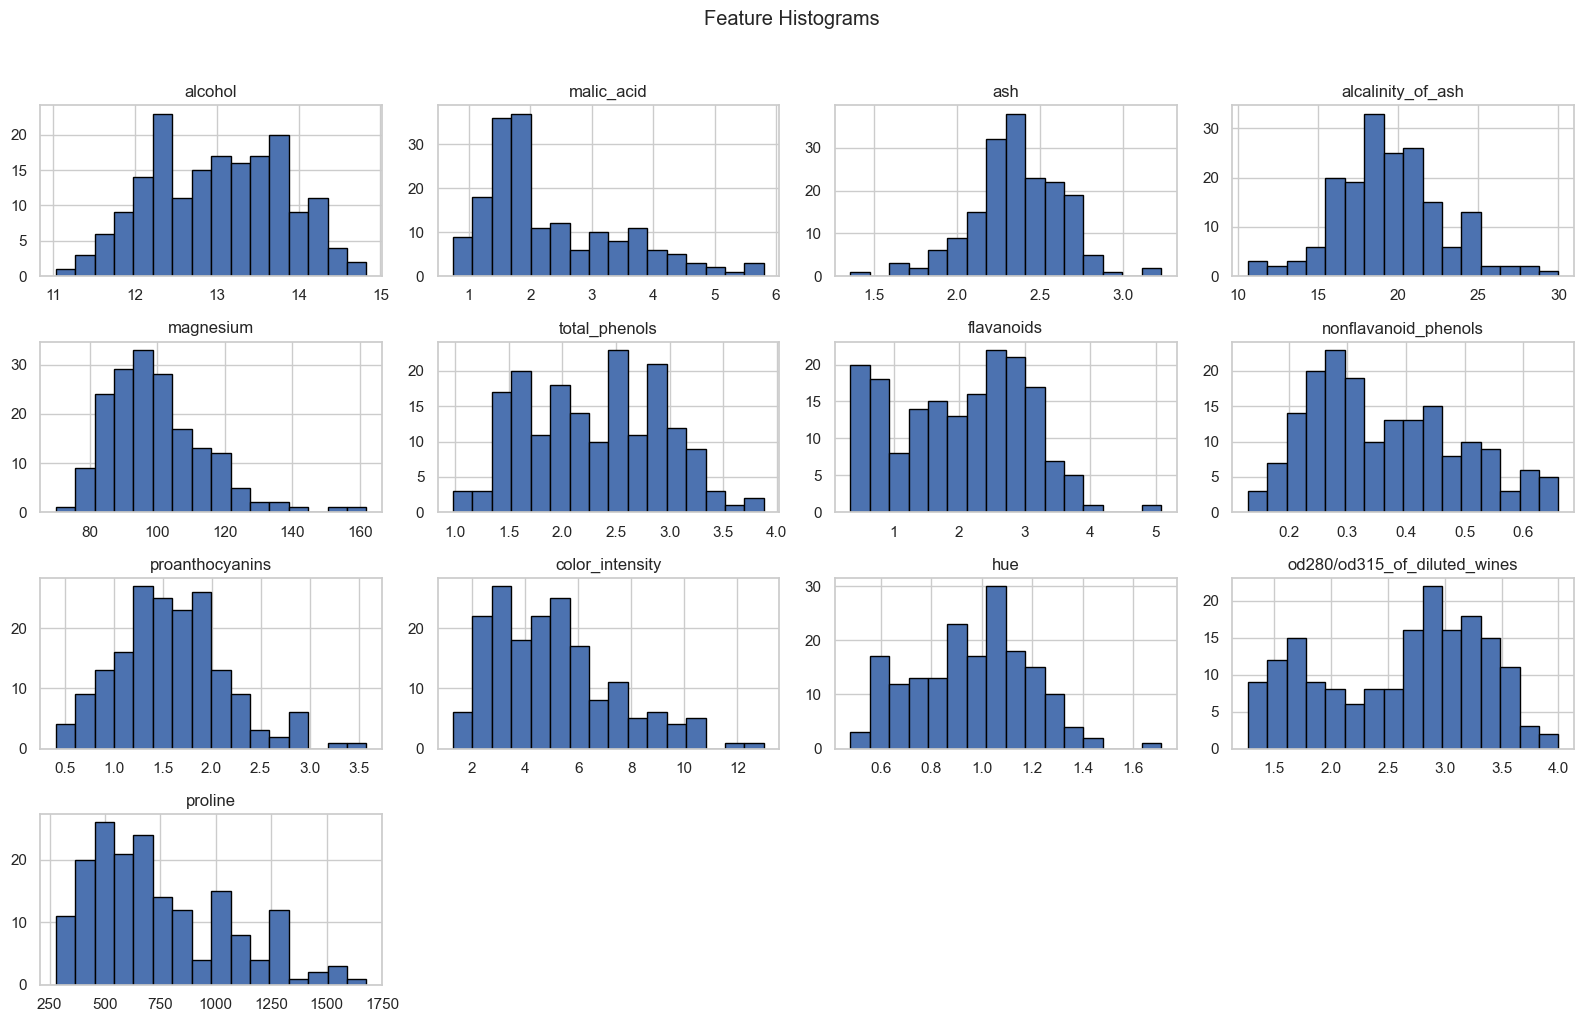

In [55]:
_ = df[feature_cols].hist(figsize=(16, 10), bins=16, edgecolor='black')
plt.suptitle('Feature Histograms', y=1.02)
plt.tight_layout()
plt.show()


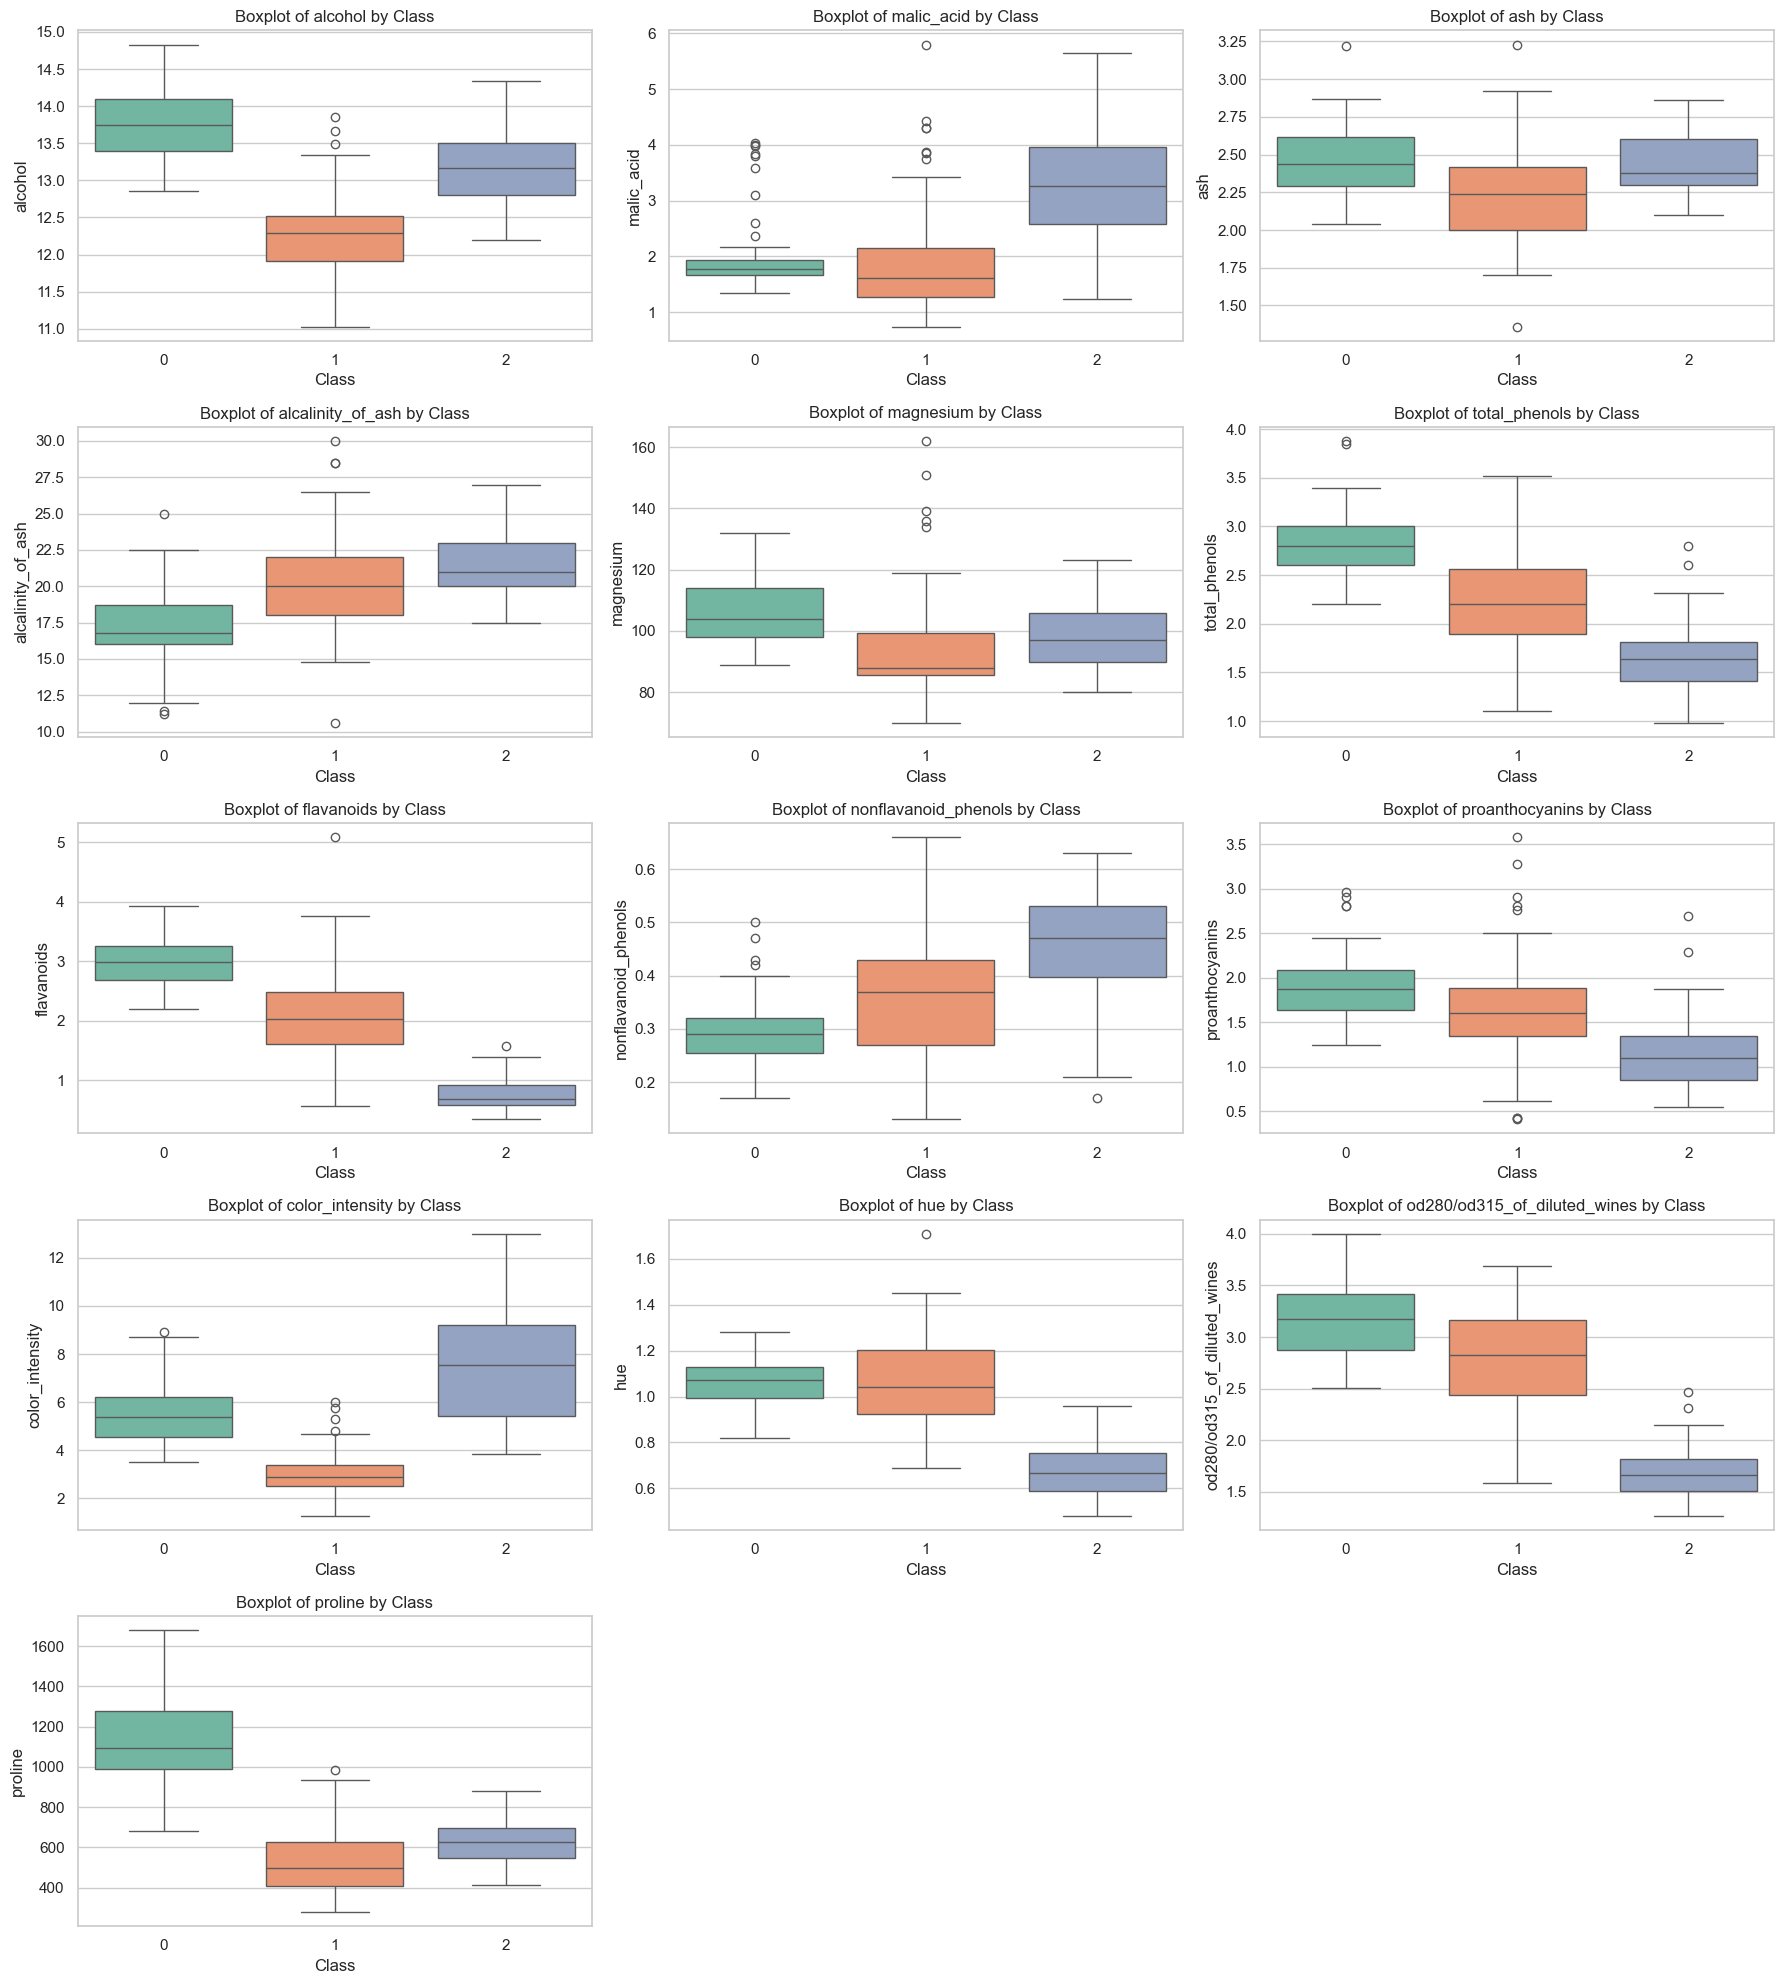

In [56]:
n_cols = 3
n_rows = int(np.ceil(len(feature_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[i], hue=target_col, palette='Set2', legend=False)
    axes[i].set_title(f'Boxplot of {col} by Class')
    axes[i].set_xlabel('Class')
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


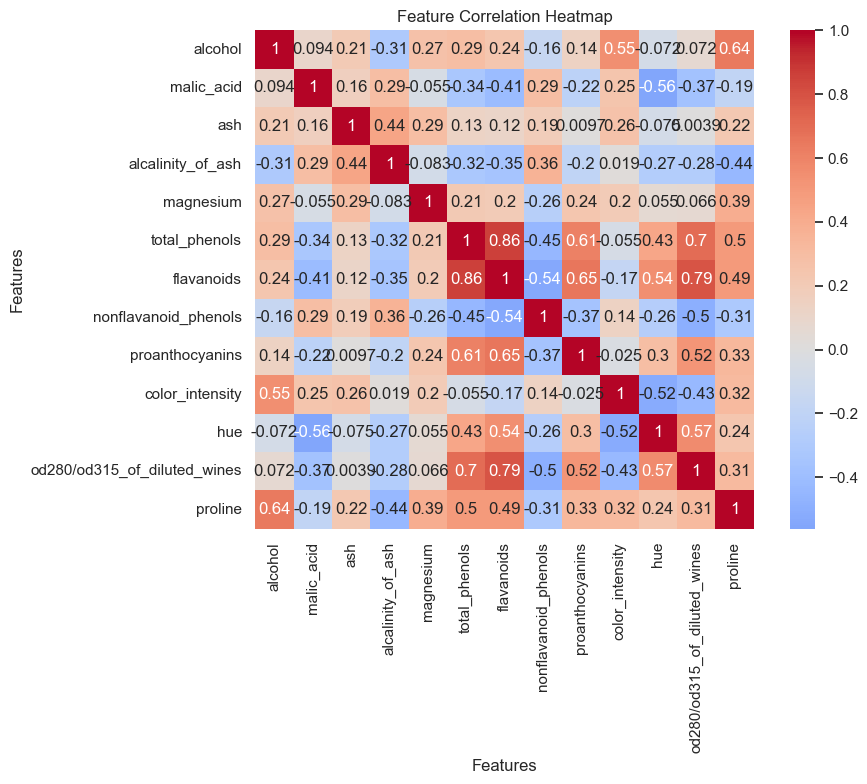

In [57]:
corr = df[feature_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0,annot=True, square=True)
plt.title('Feature Correlation Heatmap')
plt.xlabel('Features')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


## 5. Methodology

We implement ranking criteria from scratch and evaluate them using leakage-safe cross-validation.

### 5.1 Leakage-safe principle
For each fold:
1. Split training and validation data.
2. Rank features using only training data.
3. Select top-\(k\) features.
4. Fit scaler and LDA on training data only.
5. Evaluate on validation data.

### 5.2 Note on discretization
Chi-square, information gain, and gini gain require discrete bins; we discretize each numeric feature using quantile-based bins learned from the training fold.


In [58]:
def _safe_corr(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if np.std(x) == 0 or np.std(y) == 0:
        return 0.0
    return float(np.corrcoef(x, y)[0, 1])


def pearson_ranking(X, y):
    scores = {col: abs(_safe_corr(X[col].values, y)) for col in X.columns}
    return pd.Series(scores).sort_values(ascending=False)


def spearman_ranking(X, y):
    y_rank = pd.Series(y).rank().values
    scores = {col: abs(_safe_corr(pd.Series(X[col]).rank().values, y_rank)) for col in X.columns}
    return pd.Series(scores).sort_values(ascending=False)


def quantile_discretize(train_df, test_df=None, n_bins=5):
    train_binned = pd.DataFrame(index=train_df.index)
    test_binned = pd.DataFrame(index=test_df.index) if test_df is not None else None

    for col in train_df.columns:
        try:
            train_codes, bin_edges = pd.qcut(train_df[col], q=n_bins, labels=False, retbins=True, duplicates='drop')
        except ValueError:
            train_codes = pd.Series(np.zeros(len(train_df), dtype=int), index=train_df.index)
            bin_edges = np.array([train_df[col].min(), train_df[col].max()])
        train_binned[col] = pd.Series(train_codes, index=train_df.index).fillna(0).astype(int)

        if test_df is not None:
            bins = np.unique(bin_edges)
            if len(bins) < 2:
                test_binned[col] = 0
            else:
                test_codes = pd.cut(test_df[col], bins=bins, labels=False, include_lowest=True)
                test_binned[col] = pd.Series(test_codes, index=test_df.index).fillna(0).astype(int)

    return train_binned, test_binned


def _contingency(x_disc, y):
    return pd.crosstab(pd.Series(x_disc, name='x'), pd.Series(y, name='y'))


def chi2_score_feature(x_disc, y):
    ct = _contingency(x_disc, y)
    observed = ct.values.astype(float)
    row_sum = observed.sum(axis=1, keepdims=True)
    col_sum = observed.sum(axis=0, keepdims=True)
    total = observed.sum()
    expected = (row_sum @ col_sum) / total
    with np.errstate(divide='ignore', invalid='ignore'):
        terms = np.where(expected > 0, (observed - expected) ** 2 / expected, 0.0)
    return float(np.sum(terms))


def entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts[counts > 0] / total
    return float(-(p * np.log2(p)).sum())


def gini_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total == 0:
        return 0.0
    p = counts / total
    return float(1.0 - np.sum(p ** 2))


def information_gain_feature(x_disc, y):
    base_entropy = entropy_from_counts(pd.Series(y).value_counts().values)
    ct = _contingency(x_disc, y)
    total = ct.values.sum()
    cond = 0.0
    for _, row in ct.iterrows():
        w = row.sum() / total
        cond += w * entropy_from_counts(row.values)
    return float(base_entropy - cond)


def gini_gain_feature(x_disc, y):
    base_gini = gini_from_counts(pd.Series(y).value_counts().values)
    ct = _contingency(x_disc, y)
    total = ct.values.sum()
    child = 0.0
    for _, row in ct.iterrows():
        w = row.sum() / total
        child += w * gini_from_counts(row.values)
    return float(base_gini - child)


def chi2_ranking(X_disc, y):
    return pd.Series({col: chi2_score_feature(X_disc[col].values, y) for col in X_disc.columns}).sort_values(ascending=False)


def ig_ranking(X_disc, y):
    return pd.Series({col: information_gain_feature(X_disc[col].values, y) for col in X_disc.columns}).sort_values(ascending=False)


def gini_ranking(X_disc, y):
    return pd.Series({col: gini_gain_feature(X_disc[col].values, y) for col in X_disc.columns}).sort_values(ascending=False)


## 6. Feature Ranking

We compute rankings on the full dataset for reporting/inspection only (the actual model evaluation still computes ranking inside each fold).


In [59]:
X = df[feature_cols]
y = df[target_col].values

X_disc_full, _ = quantile_discretize(X, None, n_bins=5)

rankings_full = {
    'Pearson': pearson_ranking(X, y),
    'Spearman': spearman_ranking(X, y),
    'Chi2': chi2_ranking(X_disc_full, y),
    'InformationGain': ig_ranking(X_disc_full, y),
    'GiniGain': gini_ranking(X_disc_full, y),
}

for method, ranking in rankings_full.items():
    print(f'\n=== {method} Top 10 Features ===')
    display(ranking.head(10).to_frame('score'))



=== Pearson Top 10 Features ===


,score
flavanoids,0.847498
od280/od315_of_diluted_wines,0.788230
total_phenols,0.719163
proline,0.633717
hue,0.617369
alcalinity_of_ash,0.517859
proanthocyanins,0.499130
nonflavanoid_phenols,0.489109
malic_acid,0.437776
alcohol,0.328222



=== Spearman Top 10 Features ===


,score
flavanoids,0.854908
od280/od315_of_diluted_wines,0.743787
total_phenols,0.726544
hue,0.616570
proline,0.576383
proanthocyanins,0.570648
alcalinity_of_ash,0.569792
nonflavanoid_phenols,0.474205
alcohol,0.354167
malic_acid,0.346913



=== Chi2 Top 10 Features ===


,score
flavanoids,198.417311
proline,162.968615
color_intensity,154.079776
od280/od315_of_diluted_wines,149.126081
alcohol,131.875217
hue,128.934773
total_phenols,107.333571
malic_acid,93.851960
proanthocyanins,65.430278
magnesium,58.257939



=== InformationGain Top 10 Features ===


,score
flavanoids,0.889634
proline,0.766504
od280/od315_of_diluted_wines,0.704159
color_intensity,0.694847
alcohol,0.619489
hue,0.578749
total_phenols,0.526704
malic_acid,0.376286
proanthocyanins,0.312407
magnesium,0.279770



=== GiniGain Top 10 Features ===


,score
flavanoids,0.350644
proline,0.309214
color_intensity,0.296346
alcohol,0.264336
od280/od315_of_diluted_wines,0.252410
hue,0.217217
total_phenols,0.184544
malic_acid,0.166188
magnesium,0.118684
proanthocyanins,0.108759


## 7. Top-k Feature Selection

We define a set of \(k\) values and a reusable leakage-safe evaluation function.


In [60]:
k_values = [2, 4, 6, 8, 10, 12]
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def get_ranking(method, X_train, y_train, n_bins=5):
    if method == 'Pearson':
        return pearson_ranking(X_train, y_train)
    if method == 'Spearman':
        return spearman_ranking(X_train, y_train)
    if method == 'Chi2':
        X_train_disc, _ = quantile_discretize(X_train, None, n_bins=n_bins)
        return chi2_ranking(X_train_disc, y_train)
    if method == 'InformationGain':
        X_train_disc, _ = quantile_discretize(X_train, None, n_bins=n_bins)
        return ig_ranking(X_train_disc, y_train)
    if method == 'GiniGain':
        X_train_disc, _ = quantile_discretize(X_train, None, n_bins=n_bins)
        return gini_ranking(X_train_disc, y_train)
    raise ValueError(f'Unknown method: {method}')

def evaluate_method_k(method, X, y, k, n_bins=5):
    fold_acc, fold_f1, selected_sets = [], [], []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        ranking = get_ranking(method, X_train, y_train, n_bins=n_bins)
        selected = ranking.index[:k].tolist()
        selected_sets.append(set(selected))

        scaler = StandardScaler()
        X_train_sel = scaler.fit_transform(X_train[selected])
        X_test_sel = scaler.transform(X_test[selected])

        lda = LDA()
        lda.fit(X_train_sel, y_train)
        y_pred = lda.predict(X_test_sel)

        fold_acc.append(accuracy_score(y_test, y_pred))
        fold_f1.append(f1_score(y_test, y_pred, average='macro'))

    return {
        'accuracy_mean': float(np.mean(fold_acc)),
        'accuracy_std': float(np.std(fold_acc)),
        'f1_macro_mean': float(np.mean(fold_f1)),
        'f1_macro_std': float(np.std(fold_f1)),
        'selected_sets': selected_sets,
    }


## 8. Multi-Class LDA

LDA is used as the classifier for all experiments after feature selection. The model assumes class-conditional Gaussian distributions with shared covariance.

## 9. Experimental Setup

- 5-fold stratified cross-validation
- Standardization inside each fold
- Feature ranking re-computed per fold (leakage-safe)
- Metrics: Accuracy and Macro-F1
- Methods: Pearson, Spearman, Chi2, InformationGain, GiniGain


## 10. Multi-k Experiments

We evaluate each method across multiple \(k\) values.


In [61]:
methods = ['Pearson', 'Spearman', 'Chi2', 'InformationGain', 'GiniGain']

records = []
all_selected_sets = {}
for method in methods:
    for k in k_values:
        out = evaluate_method_k(method, X, y, k, n_bins=5)
        records.append({
            'method': method,
            'k': k,
            'accuracy_mean': out['accuracy_mean'],
            'accuracy_std': out['accuracy_std'],
            'f1_macro_mean': out['f1_macro_mean'],
            'f1_macro_std': out['f1_macro_std'],
        })
        all_selected_sets[(method, k)] = out['selected_sets']

results_df = pd.DataFrame(records).sort_values(['method', 'k']).reset_index(drop=True)
display(results_df)


,method,k,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
0,Chi2,2,0.859048,0.073687,0.862864,0.071623
1,Chi2,4,0.955079,0.033898,0.957395,0.032641
2,Chi2,6,0.966032,0.028062,0.967795,0.025273
3,Chi2,8,0.977460,0.021299,0.978231,0.019654
4,Chi2,10,0.977619,0.011195,0.978215,0.010967
5,Chi2,12,0.966349,0.021133,0.967904,0.019739
6,GiniGain,2,0.892381,0.066755,0.894915,0.064582
7,GiniGain,4,0.960635,0.038249,0.962531,0.036672
8,GiniGain,6,0.966032,0.028062,0.967795,0.025273
9,GiniGain,8,0.977460,0.021299,0.978231,0.019654


## 11. Performance Evaluation

We visualize mean CV performance versus \(k\) and inspect the best overall setting.


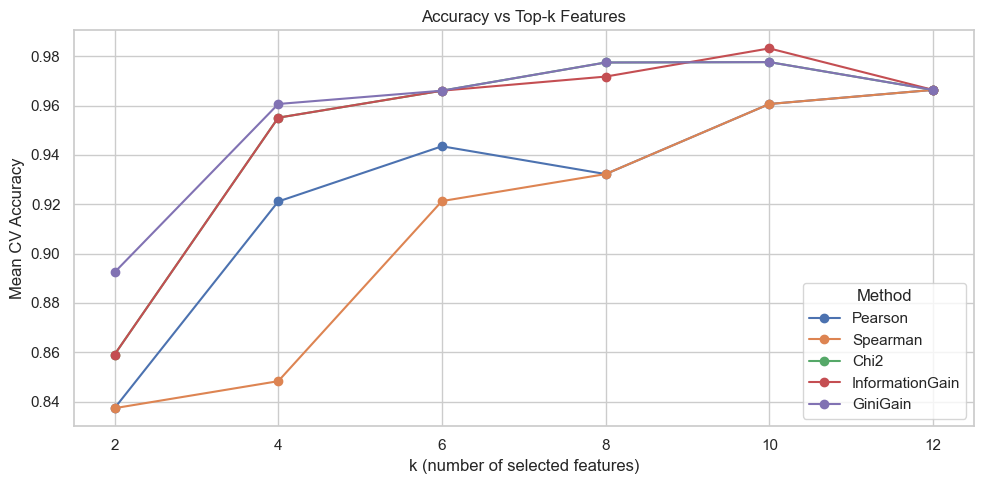

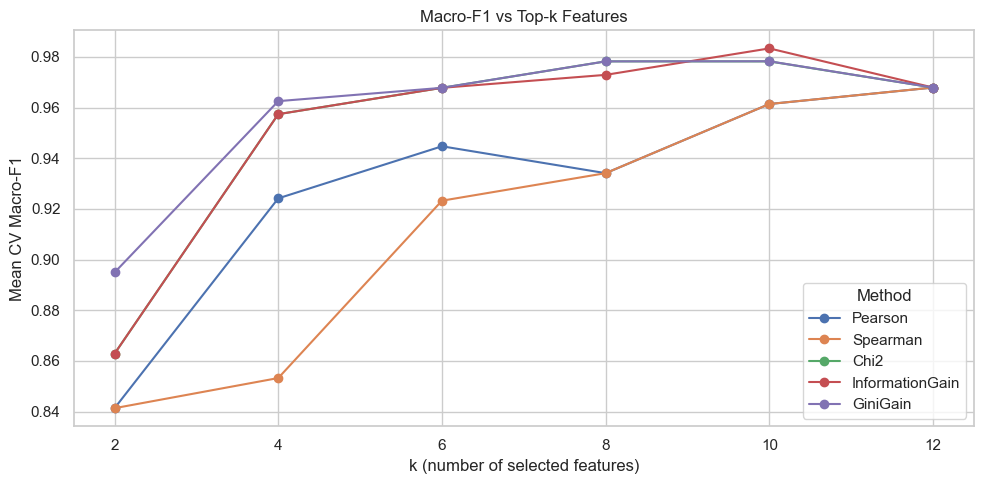

Best setting by mean accuracy:


,method,k,accuracy_mean,accuracy_std,f1_macro_mean,f1_macro_std
16,InformationGain,10,0.983175,0.013741,0.983351,0.01363


In [62]:
plt.figure(figsize=(10, 5))
for method in methods:
    subset = results_df[results_df['method'] == method]
    plt.plot(subset['k'], subset['accuracy_mean'], marker='o', label=method)

plt.title('Accuracy vs Top-k Features')
plt.xlabel('k (number of selected features)')
plt.ylabel('Mean CV Accuracy')
plt.legend(title='Method')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
for method in methods:
    subset = results_df[results_df['method'] == method]
    plt.plot(subset['k'], subset['f1_macro_mean'], marker='o', label=method)

plt.title('Macro-F1 vs Top-k Features')
plt.xlabel('k (number of selected features)')
plt.ylabel('Mean CV Macro-F1')
plt.legend(title='Method')
plt.tight_layout()
plt.show()

best_row = results_df.sort_values('accuracy_mean', ascending=False).iloc[0]
print('Best setting by mean accuracy:')
display(best_row.to_frame().T)


In [63]:
import numpy as np

class LDA:
    
    def __init__(self, n_components = None):
        self.n_components = n_components
        self.eigenvectors = None
        self.classes_ = None
        self.means_ = None

    def fit(self, x, y):
        x = np.array(x)
        y = np.array(y)

        self.classes_ = np.unique(y)
        overall_mean = np.mean(x, axis=0)
        n_features = x.shape[1]

        # Compute class means for prediction
        self.means_ = {}
        for c in self.classes_:
            x_c = x[y==c]
            self.means_[c] = np.mean(x_c, axis=0)

        Sb = np.zeros((n_features, n_features))
        Sw = np.zeros((n_features, n_features))

        for c in self.classes_:
            x_c = x[y==c]
            x_c_mean = self.means_[c]
            n_class_samples = len(x_c)

            mean_diff = (x_c_mean - overall_mean).reshape(-1,1)
            Sb += n_class_samples * (mean_diff @ mean_diff.T)
            Sw += (x_c - x_c_mean).T @ (x_c - x_c_mean)

        A = np.linalg.inv(Sw) @ Sb
        eigenvalues, eigenvectors = np.linalg.eig(A)

        sorted_idx = np.argsort(eigenvalues)[::-1]
        sorted_eigenvectors = eigenvectors[:, sorted_idx]

        if self.n_components:
            sorted_eigenvectors = sorted_eigenvectors[:, :self.n_components]

        self.eigenvectors = sorted_eigenvectors
        return self

    def get_eigenvectors(self):
        return self.eigenvectors

    def transform(self, x):
        return x @ self.eigenvectors
    
    def fit_transform(self, x, y):
        self.fit(x, y)
        return self.transform(x)
    
    def predict(self, x):
        """Predict class labels by finding closest class mean in transformed space."""
        x = np.array(x)
        x_transformed = self.transform(x)
        
        predictions = []
        for sample in x_transformed:
            # Project class means to transformed space
            min_dist = float('inf')
            closest_class = None
            
            for c in self.classes_:
                mean_transformed = self.means_[c] @ self.eigenvectors
                dist = np.sum((sample - mean_transformed) ** 2)
                if dist < min_dist:
                    min_dist = dist
                    closest_class = c
            
            predictions.append(closest_class)
        
        return np.array(predictions)

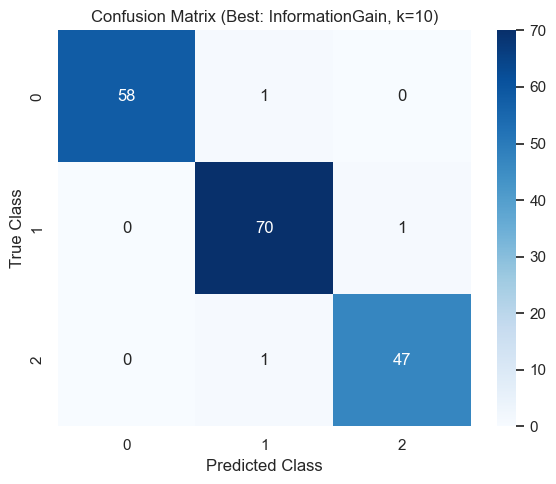

              precision    recall  f1-score   support

           0     1.0000    0.9831    0.9915        59
           1     0.9722    0.9859    0.9790        71
           2     0.9792    0.9792    0.9792        48

    accuracy                         0.9831       178
   macro avg     0.9838    0.9827    0.9832       178
weighted avg     0.9833    0.9831    0.9832       178



In [64]:
best_method = best_row['method']
best_k = int(best_row['k'])

oof_true, oof_pred = [], []
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    ranking = get_ranking(best_method, X_train, y_train, n_bins=5)
    selected = ranking.index[:best_k].tolist()

    scaler = StandardScaler()
    X_train_sel = scaler.fit_transform(X_train[selected])
    X_test_sel = scaler.transform(X_test[selected])

    lda = LDA()
    lda.fit(X_train_sel, y_train)
    preds = lda.predict(X_test_sel)

    oof_true.extend(y_test)
    oof_pred.extend(preds)

cm = confusion_matrix(oof_true, oof_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix (Best: {best_method}, k={best_k})')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.tight_layout()
plt.show()

print(classification_report(oof_true, oof_pred, digits=4))


## 12. Stability Analysis

Stability is measured by average pairwise **Jaccard similarity** between selected top-\(k\) sets across CV folds. Higher values indicate more consistent feature selection.


,method,k,mean_jaccard
0,Pearson,2,1.000000
1,Pearson,4,0.840000
2,Pearson,6,0.800000
3,Pearson,8,1.000000
4,Pearson,10,1.000000
5,Pearson,12,1.000000
6,Spearman,2,1.000000
7,Spearman,4,0.760000
8,Spearman,6,0.742857
9,Spearman,8,1.000000


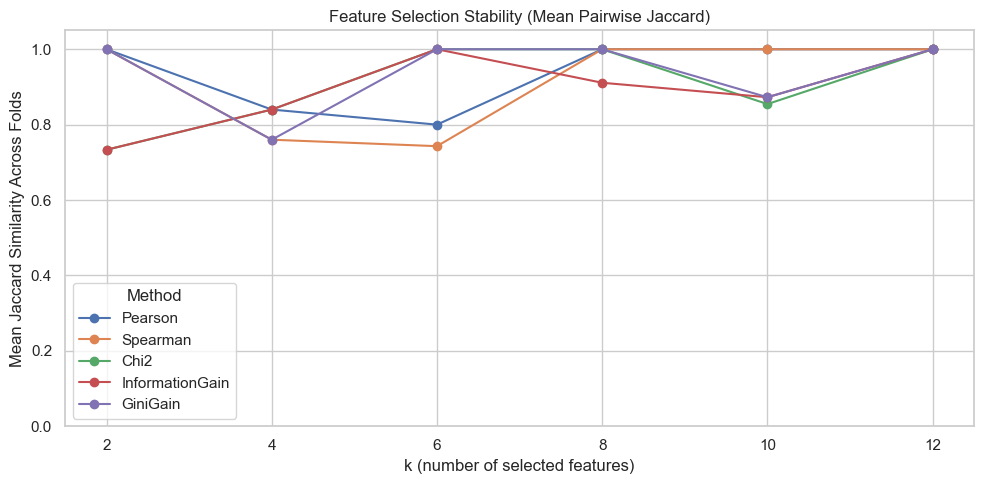

In [65]:
def mean_pairwise_jaccard(feature_sets):
    vals = []
    for i in range(len(feature_sets)):
        for j in range(i + 1, len(feature_sets)):
            a, b = feature_sets[i], feature_sets[j]
            vals.append(len(a & b) / len(a | b))
    return float(np.mean(vals)) if vals else np.nan

stability_records = []
for method in methods:
    for k in k_values:
        jac = mean_pairwise_jaccard(all_selected_sets[(method, k)])
        stability_records.append({'method': method, 'k': k, 'mean_jaccard': jac})

stability_df = pd.DataFrame(stability_records)
display(stability_df)

plt.figure(figsize=(10, 5))
for method in methods:
    subset = stability_df[stability_df['method'] == method]
    plt.plot(subset['k'], subset['mean_jaccard'], marker='o', label=method)

plt.title('Feature Selection Stability (Mean Pairwise Jaccard)')
plt.xlabel('k (number of selected features)')
plt.ylabel('Mean Jaccard Similarity Across Folds')
plt.ylim(0, 1.05)
plt.legend(title='Method')
plt.tight_layout()
plt.show()


## 13. Sensitivity Analysis

We test sensitivity to discretization granularity (number of bins) for methods that require discrete inputs: Chi2, InformationGain, and GiniGain.


,method,bins,accuracy_mean,f1_macro_mean
0,Chi2,3,0.971587,0.973439
1,Chi2,5,0.966032,0.967795
2,Chi2,7,0.960476,0.962469
3,Chi2,10,0.960476,0.962469
4,InformationGain,3,0.971587,0.973439
5,InformationGain,5,0.966032,0.967795
6,InformationGain,7,0.971587,0.973439
7,InformationGain,10,0.966032,0.968113
8,GiniGain,3,0.971587,0.973439
9,GiniGain,5,0.966032,0.967795


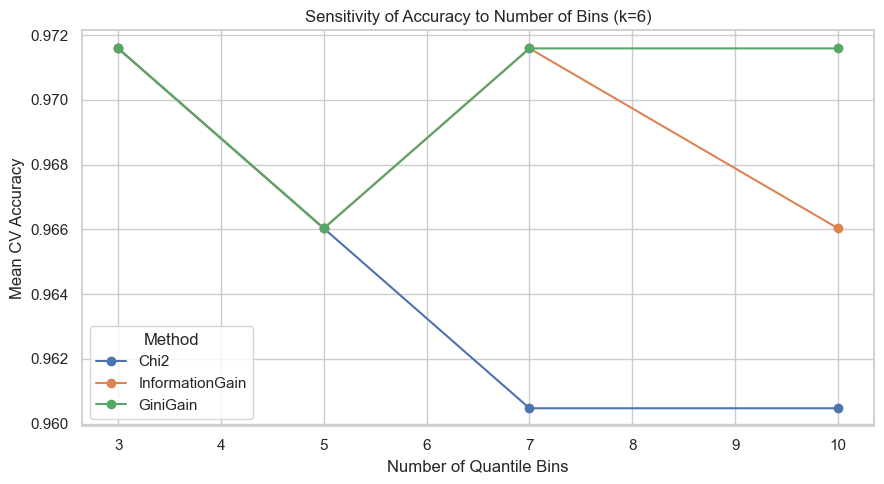

In [66]:
bin_values = [3, 5, 7, 10]
k_sens = 6
sens_methods = ['Chi2', 'InformationGain', 'GiniGain']

sens_records = []
for method in sens_methods:
    for bins in bin_values:
        out = evaluate_method_k(method, X, y, k=k_sens, n_bins=bins)
        sens_records.append({
            'method': method,
            'bins': bins,
            'accuracy_mean': out['accuracy_mean'],
            'f1_macro_mean': out['f1_macro_mean'],
        })

sensitivity_df = pd.DataFrame(sens_records)
display(sensitivity_df)

plt.figure(figsize=(9, 5))
for method in sens_methods:
    subset = sensitivity_df[sensitivity_df['method'] == method]
    plt.plot(subset['bins'], subset['accuracy_mean'], marker='o', label=method)

plt.title(f'Sensitivity of Accuracy to Number of Bins (k={k_sens})')
plt.xlabel('Number of Quantile Bins')
plt.ylabel('Mean CV Accuracy')
plt.legend(title='Method')
plt.tight_layout()
plt.show()


## 14. Results Discussion

Key observations from the experiments:

- Performance generally improves with larger \(k\), then saturates.
- Correlation-based and impurity/information-based filters can produce different rankings, especially at low \(k\).
- Stability tends to increase with \(k\), since larger subsets overlap more across folds.
- Discretization-sensitive methods (Chi2/IG/Gini) may vary slightly with bin count, but broad trends remain similar.

These results illustrate the trade-off between compact feature subsets, predictive performance, and ranking robustness.


## 15. Conclusion

This notebook provides a complete, consolidated academic workflow for filter-based dimensionality reduction with Multi-Class LDA.

It includes:
- Dataset inspection and validation
- Unified EDA in the same notebook
- From-scratch feature selection metrics
- Leakage-safe CV experiments across multiple \(k\)
- Performance, stability, and sensitivity analyses

The final framework can be directly extended to other multi-class datasets and additional filter/wrapper criteria.
